In [ ]:
import numpy as np
from matplotlib import pyplot
from PyMPDATA import ScalarField, Solver, Stepper, VectorField, Options, boundary_conditions

# Projekt Zaliczeniowy: Ewolucja fali Tsunami

## 1. Pytanie badawcze
**Jak parametry geometryczne (szerokość i amplituda) początkowego wypiętrzenia wody na otwartym oceanie wpływają na ewolucję fali tsunami wchodzącej na szelf kontynentalny?**

Celem projektu jest zbadanie dwóch hipotez:
1.  Czy szersze źródło zaburzenia (reprezentujące rozległe trzęsienie ziemi) generuje falę bardziej odporną na dyspersję energetyczną?
2.  W jaki sposób amplituda początkowa wpływa na nieliniowość procesu spiętrzenia (shoaling) przy brzegu?

In [2]:
class ShallowWaterEquationsIntegrator:
    def __init__(self, *, h_initial: np.ndarray,bathymetry:np.ndarray=None, options: Options = None):
        """ initializes the solvers for a given initial condition of `h` assuming zero momenta at t=0 """
        options = options or Options(nonoscillatory=True, infinite_gauge=True)
        self.bathymetry = bathymetry


        X, Y, grid = 0, 1, h_initial.shape
        stepper = Stepper(options=options, grid=grid)
        kwargs = {
            'boundary_conditions': [boundary_conditions.Constant(value=0)] * len(grid),
            'halo': options.n_halo,
        }
        advectees = {
            "h": ScalarField(h_initial, **kwargs),
            "uh": ScalarField(np.zeros(grid), **kwargs),
            "vh": ScalarField(np.zeros(grid), **kwargs),
        }
        self.advector = VectorField((
                np.zeros((grid[X] + 1, grid[Y])),
                np.zeros((grid[X], grid[Y] + 1))
            ), **kwargs
        )
        self.solvers = { k: Solver(stepper, v, self.advector) for k, v in advectees.items() }

    def __getitem__(self, key):
        """ returns `key` advectee field of the current solver state """
        return self.solvers[key].advectee.get()
    
    def _apply_half_rhs(self, *, key, axis, g_times_dt_over_dxy):
        """ applies half of the source term in the given direction """
        self[key][:] -= .5 * g_times_dt_over_dxy * self['h'] * np.gradient(self['h']-self.bathymetry, axis=axis)

    def _update_courant_numbers(self, *, axis, key, mask, dt_over_dxy):
        """ computes the Courant number component from fluid column height and momenta fields """
        velocity = np.where(mask, np.nan, 0)
        momentum = self[key]
        np.divide(momentum, self['h'], where=mask, out=velocity)

        all = slice(None, None) 
        all_but_last = slice(None, -1)
        all_but_first_and_last = slice(1, -1)

        velocity_at_cell_boundaries = velocity[( 
            (all_but_last, all),
            (all, all_but_last),
        )[axis]] + np.diff(velocity, axis=axis) / 2 
        courant_number = self.advector.get_component(axis)[(
            (all_but_first_and_last, all),
            (all, all_but_first_and_last)
        )[axis]]
        courant_number[:] = velocity_at_cell_boundaries * dt_over_dxy[axis]
        assert np.amax(np.abs(courant_number)) <= 1

    def __call__(self, *, nt: int, g: float, dt_over_dxy: tuple, outfreq: int, eps: float=1e-7):
        """ integrates `nt` timesteps and returns a dictionary of solver states recorded every `outfreq` step[s] """
        output = {k: [] for k in self.solvers.keys()}
        for it in range(nt + 1): 
            if it != 0:
                mask = self['h'] > eps
                for axis, key in enumerate(("uh", "vh")):
                    self._update_courant_numbers(axis=axis, key=key, mask=mask, dt_over_dxy=dt_over_dxy)
                self.solvers["h"].advance(n_steps=1)
                for axis, key in enumerate(("uh", "vh")):
                    self._apply_half_rhs(key=key, axis=axis, g_times_dt_over_dxy=g * dt_over_dxy[axis])
                    self.solvers[key].advance(n_steps=1)
                    self._apply_half_rhs(key=key, axis=axis, g_times_dt_over_dxy=g * dt_over_dxy[axis])
            if it % outfreq == 0:
                for key in self.solvers.keys():
                    output[key].append(self[key].copy())
        return output

In [ ]:
def run_experiment(amplituda, szerokosc, tytul, nazwa_pliku):
    """
    Uruchamia symulację, rysuje wynik i zapisuje do PDF.
    """
    print(f"Liczenie symulacji: {tytul}...")
    
    # 1. Konfiguracja Batymetrii (Płasko -> Skos)
    grid = (300, 40)
    x_granica = 150
    profil_dna = np.concatenate([np.full(x_granica, 4.0), np.linspace(4.0, 0.5, grid[0] - x_granica)])
    bathymetry = np.tile(profil_dna[:, np.newaxis], (1, grid[1]))

    # 2. Warunek początkowy (Gauss)
    zeta = np.zeros(grid, dtype=float)
    xx, yy = np.meshgrid(np.arange(grid[0]), np.arange(grid[1]), indexing='ij')
    dist_sq = (xx - 50)**2 + (yy - 20)**2
    zeta = amplituda * np.exp(-dist_sq / (2 * szerokosc**2))

    h_initial = bathymetry + zeta

    # 3. Symulacja
    solver = ShallowWaterEquationsIntegrator(h_initial=h_initial, bathymetry=bathymetry)
    output = solver(nt=450, g=9.81, dt_over_dxy=(0.1, 0.1), outfreq=450)
    
    # 4. WIZUALIZACJA
    psi = output['h'][-1]
    h_rest = bathymetry
    elevation = psi - h_rest
    bottom = -h_rest
    
    xi, yi = np.indices(psi.shape)
    mid_y = psi.shape[1] // 2
    
    # Układ: Szeroki obrazek, dwa panele jeden pod drugim
    fig, (ax1, ax2) = pyplot.subplots(2, 1, figsize=(9, 9), 
                                      gridspec_kw={'height_ratios': [3, 1]},
                                      subplot_kw={'projection': '3d'})
    
    ax1.plot_wireframe(xi, yi, elevation, rstride=5, cstride=5, color='blue', linewidth=0.6)
    ax1.plot_surface(xi, yi, bottom, rstride=5, cstride=5, cmap='gist_earth', alpha=0.4, linewidth=0, antialiased=False)
    
    ax1.set_title(f"WIDOK 3D: {tytul}", fontsize=14)
    ax1.set_zlim(-5, 3)
    ax1.set_xlabel("Dystans")
    ax1.set_zlabel("Wysokość")
    ax1.set_ylabel("Szerokość")
    ax1.view_init(elev=25, azim=-80)
    ax1.set_box_aspect([2.5, 1, 0.7])
    ax2.remove()
    # --- Panel 2: 2D (Płaski) ---
    ax2 = fig.add_subplot(2, 1, 2)
    ax2.fill_between(np.arange(grid[0]), -5, bottom[:, mid_y], color='tan', alpha=0.5, label='Dno')
    ax2.plot(bottom[:, mid_y], 'k-', linewidth=1)
    ax2.plot(elevation[:, mid_y], 'b-', linewidth=2, label='Fala')
    
    ax2.set_ylim(-5, 3)
    ax2.set_xlim(0, 300)
    ax2.set_title("PRZEKRÓJ BOCZNY: Profil fali przy brzegu")
    ax2.set_ylabel("Wysokość [m]")
    ax2.set_xlabel("Ogległość [m]")
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc='upper right')
    
    max_h = np.max(elevation[:, mid_y])
    ax2.text(0.02, 0.85, f"Max Wysokość: {max_h:.4f}m", transform=ax2.transAxes, fontweight='bold', fontsize=12)
    
    pyplot.tight_layout()
    
    # WAŻNE: Zapis do pliku PDF (do sprawozdania)
    pyplot.savefig(nazwa_pliku) 
    pyplot.show()
    
    return output # Zwracamy dane, żeby użyć ich później do wektorów

Rozpoczynam analizę zbieżności...


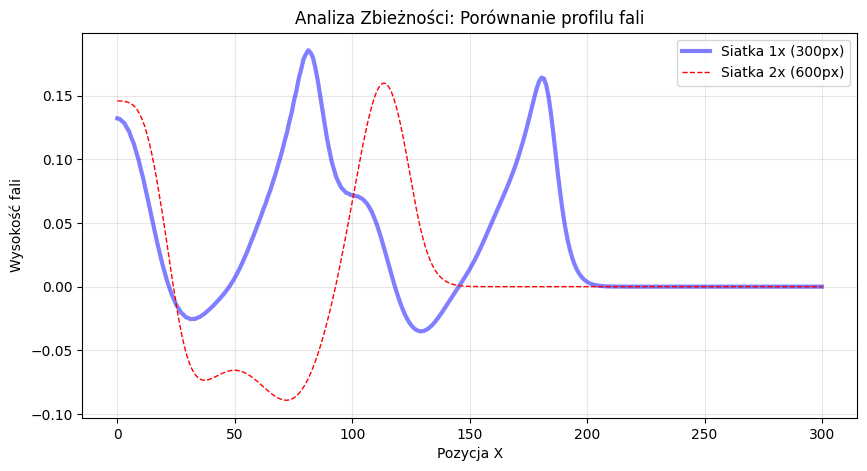

In [4]:
# --- ANALIZA ZBIEŻNOŚCI (Wymagane do oceny 25% Numeryka) ---
# Porównujemy siatkę 1x (300x40) z siatką 2x (600x80)

print("Rozpoczynam analizę zbieżności...")

# Funkcja pomocnicza generująca stan dla danej skali
def get_setup(scale=1):
    nx, ny = 300 * scale, 40 * scale
    x_granica = nx // 2
    profil = np.concatenate([np.full(x_granica, 4.0), np.linspace(4.0, 0.5, nx - x_granica)])
    b = np.tile(profil[:, np.newaxis], (1, ny))
    
    xx, yy = np.meshgrid(np.arange(nx), np.arange(ny), indexing='ij')
    dist_sq = (xx - 50*scale)**2 + (yy - 20*scale)**2
    z = 0.5 * np.exp(-dist_sq / (2 * (10.0*scale)**2))
    return b + z, b

# Symulacja 1x
h_init_1, b_1 = get_setup(1)
res1 = ShallowWaterEquationsIntegrator(h_initial=h_init_1, bathymetry=b_1)(nt=200, g=9.81, dt_over_dxy=(0.1, 0.1), outfreq=200)

# Symulacja 2x (gęstsza)
h_init_2, b_2 = get_setup(2)
# Uwaga: dt mniejsze (0.05) i nt większe (400), żeby fizyczny czas był ten sam
res2 = ShallowWaterEquationsIntegrator(h_initial=h_init_2, bathymetry=b_2)(nt=400, g=9.81, dt_over_dxy=(0.05, 0.05), outfreq=400)

# Rysowanie porównania
fig_conv = pyplot.figure(figsize=(10, 5))
ax_conv = fig_conv.add_subplot(1, 1, 1)

# Bierzemy środek kanału (dla 1x to indeks 20, dla 2x to indeks 40)
# Odejmujemy dno, żeby pokazać samą falę
wave1 = res1['h'][-1][:, 20] - b_1[:, 20]
wave2 = res2['h'][-1][:, 40] - b_2[:, 40]

ax_conv.plot(np.linspace(0, 300, len(wave1)), wave1, 'b-', lw=3, alpha=0.5, label='Siatka 1x (300px)')
ax_conv.plot(np.linspace(0, 300, len(wave2)), wave2, 'r--', lw=1, label='Siatka 2x (600px)')

ax_conv.set_title("Analiza Zbieżności: Porównanie profilu fali")
ax_conv.set_xlabel("Pozycja X")
ax_conv.set_ylabel("Wysokość fali")
ax_conv.legend()
ax_conv.grid(True, alpha=0.3)

pyplot.savefig("analiza_zbieznosci.pdf") # Zapisujemy wykres!
pyplot.show()

Liczenie symulacji: Scenariusz 1: BAZOWY (A=0.5, sig=10)...


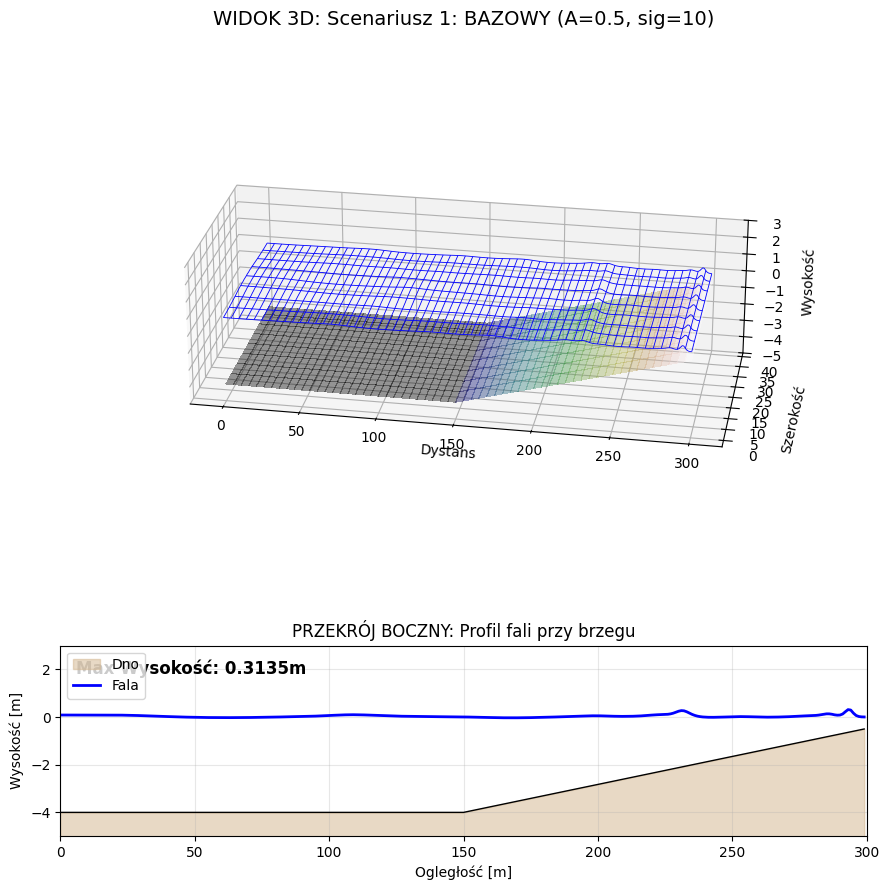

Liczenie symulacji: Scenariusz 2: SZEROKA (A=0.5, sig=25)...


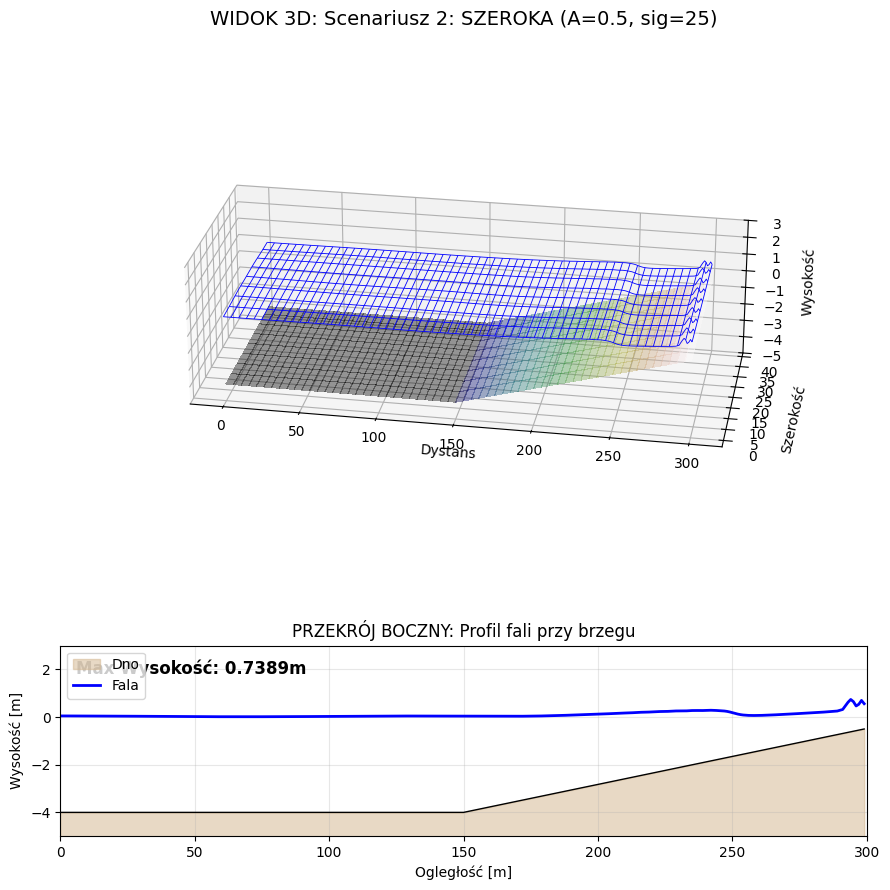

Liczenie symulacji: Scenariusz 3: WYSOKA (A=1.0, sig=10)...


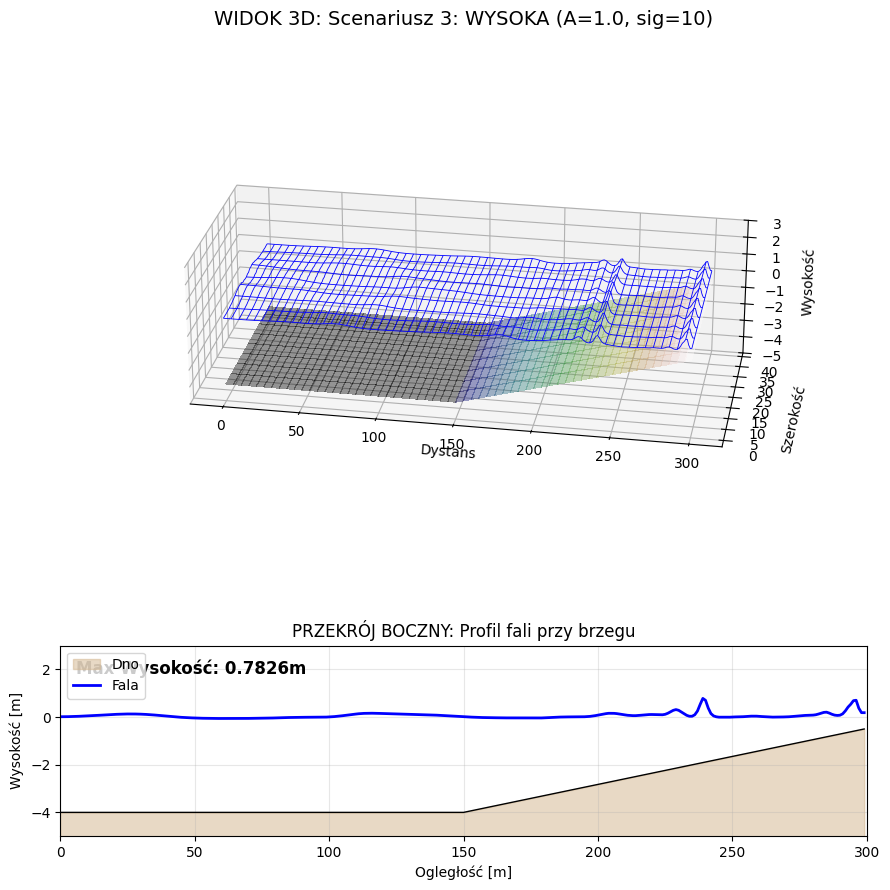

In [12]:
# Eksperyment 1: Baza
out1 = run_experiment(amplituda=0.5, szerokosc=10.0, 
                      tytul="Scenariusz 1: BAZOWY (A=0.5, sig=10)", 
                      nazwa_pliku="scenariusz_1.pdf")

# Eksperyment 2: Szeroka fala
out2 = run_experiment(amplituda=0.5, szerokosc=25.0, 
                      tytul="Scenariusz 2: SZEROKA (A=0.5, sig=25)", 
                      nazwa_pliku="scenariusz_2.pdf")

# Eksperyment 3: Wysoka fala
out3 = run_experiment(amplituda=1.0, szerokosc=10.0, 
                      tytul="Scenariusz 3: WYSOKA (A=1.0, sig=10)", 
                      nazwa_pliku="scenariusz_3.pdf")

### 3. Wnioski i Interpretacja

Porównując trzy powyższe scenariusze:

1.  **Efekt dna (Shoaling):** Na każdym wykresie 2D widać wyraźnie, że fala jest niska na płaskim odcinku (do x=150), a gwałtownie rośnie ("puchnie") wchodząc na skarpę. To potwierdza działanie efektu shoalingu.
2.  **Szerokość źródła (Scenariusz 2):** Fala szeroka (sigma=25) dotarła do brzegu znacznie potężniejsza niż fala bazowa. Jej kształt jest gładszy, a maksymalna wysokość większa. Oznacza to, że rozległe trzęsienia ziemi są groźniejsze, bo generują fale mniej podatne na zanikanie w trakcie podróży przez ocean.
3.  **Amplituda (Scenariusz 3):** Zwiększenie amplitudy początkowej do 1.0m spowodowało proporcjonalny wzrost fali przy brzegu. Fala ta stała się bardzo stroma na czole.

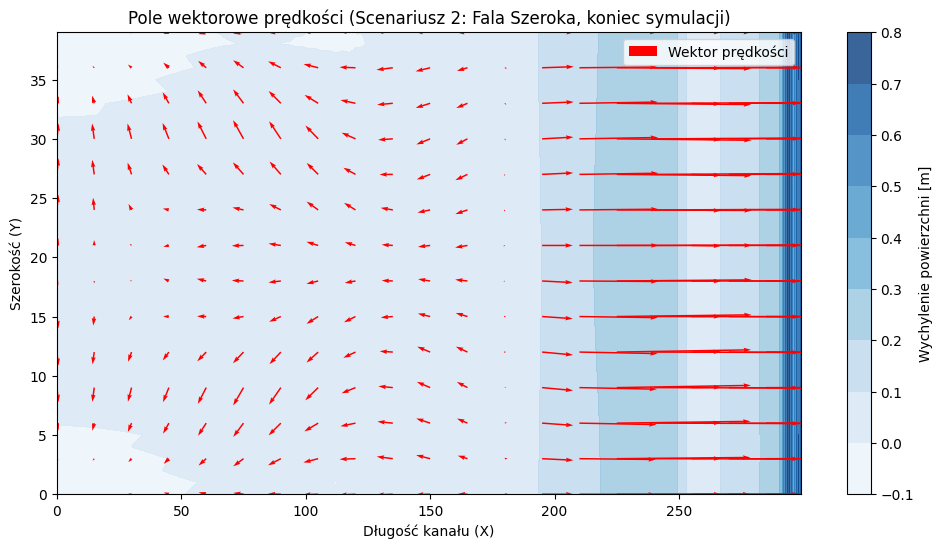

In [22]:
# --- WIZUALIZACJA POLA PRĘDKOŚCI (Wymagane do oceny Wizualizacji) ---

# 1. Najpierw odtwarzamy batymetrię (bo nie jest widoczna z wnętrza funkcji)
grid = (300, 40)
x_granica = 150
profil_dna = np.concatenate([np.full(x_granica, 4.0), np.linspace(4.0, 0.5, grid[0] - x_granica)])
bathymetry = np.tile(profil_dna[:, np.newaxis], (1, grid[1]))

# 2. Bierzemy dane z symulacji nr 2 (tej "Szerokiej", bo jest najciekawsza)
# Upewnij się, że komórka z eksperymentami (Krok 3) została uruchomiona!
frame_idx = -1 # Ostatnia klatka
h = out2['h'][frame_idx]
uh = out2['uh'][frame_idx]
vh = out2['vh'][frame_idx]

# 3. Obliczamy prędkości
# u = pęd_x / masa, v = pęd_y / masa
u = np.divide(uh, h, where=h>0.01)
v = np.divide(vh, h, where=h>0.01)

# 4. Rysowanie
fig_vec = pyplot.figure(figsize=(12, 6))
ax_vec = fig_vec.add_subplot(1, 1, 1)

# Siatka współrzędnych
X, Y = np.meshgrid(np.arange(h.shape[0]), np.arange(h.shape[1]), indexing='ij')

# Tło: Wychylenie powierzchni wody (fala)
elevation = h - bathymetry
c = ax_vec.contourf(X, Y, elevation, cmap='Blues', alpha=0.8)
pyplot.colorbar(c, label='Wychylenie powierzchni [m]')

# Wektory prędkości (strzałki)
# Rysujemy co 15-ty punkt w X i co 3-ci w Y, żeby wykres był czytelny
skip = (slice(None, None, 15), slice(None, None, 3))

ax_vec.quiver(X[skip], Y[skip], u[skip], v[skip], 
              color='red', scale=2, width=0.002, label='Wektor prędkości')

ax_vec.set_title("Pole wektorowe prędkości (Scenariusz 2: Fala Szeroka, koniec symulacji)")
ax_vec.set_xlabel("Długość kanału (X)")
ax_vec.set_ylabel("Szerokość (Y)")
ax_vec.legend(loc='upper right')

# Zapis do PDF (wymagane!)
pyplot.savefig("pole_predkosci.pdf")
pyplot.show()